# Iceberg simulation example
Documented example of simulations of individual icebergs using openberg (version: github/lia-f-h/opendrift_2026) and wrapper "simu_late" (see src/simu_late.py)

In [1]:
# Import of packages (utils.py) and additional functions (utils.py, simu_late.py)
from src.utils import *
from src.simu_late import *

In [2]:
# NEW SIMULATION

# Define the arguments in a dictionary, here "dict_in"
dict_in = {'simulationname':'simulation1'} #Adapt, overwrites last unnamed simulation otherwise

# Model configurations: (Most recommended configurations are set to default already)
dict_in['config'] = {'seed:wind_form_drag_coef':1.5, 'seed:water_form_drag_coef':1.5,}

# Input data
    #Supply as list of a) urls, b) data-id's for copernicus marine, c) predefined keyword (uses pre-defined informations), 
    #d) dictionary of new input info containing a url or path to a local file under key 'ref'.
    #Check out pre-defined information calling "inputmapping"
dict_in['input']=['cmems_mod_arc_phy_anfc_6km_detided_PT1H-i',
                  #'mfwam',
                  {'era5':{'ref':'../input/era5_2023_09_10-18.nc'}}]

# Initial information
n=2 #Number of icebergs seeded in same simulation
    #Example for Randomised iceberg size
#randspace=np.random.rand(n)
#lengths, widths = randspace*(87-75)+75, randspace**(80-65)+65
    #Set iceberg seeding
lengths, widths, sails, drafts = 81, 72, 2.9914802407484546, 21.199466273020537 #in meters
lat, lon = 80.5794, 37.81915 #in decimaldegrees
dict_in['seed']= {'lon': lon, 'lat': lat,
            'length': lengths, 'width': widths, 
            'sail': sails, 'draft': drafts, 
            'number': n, 'radius':50, #here, n icebergs will be distributed randomly in a area up to 50m around the lat,lon
           'time': datetime(2023,9,10,12,36)}
# Additional information needed to run the simulations
dict_in['run']={'duration':timedelta(days=0.5), #duration of simulations, if negativ, runs backward
                'loglevel':50, #controls level of logging information: 10: all infos, 20: medium, 50:basic
                'logfile':True} #controls if logfile with wanrings and debugging information is returned

o1 = simu_late(dict_in) #Check out simu_lat.py for additional documentation.
                        #o1 can be used to create plots. The simulations results and the logging infos are saved to seperate files in the results folder.

Input used:  ['cmems_mod_arc_phy_anfc_6km_detided_PT1H-i', 'era5']


Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 31.50it/s]
INFO - 2026-04-24T14:07:07Z - Selected dataset version: "202311"
INFO - 2026-04-24T14:07:07Z - Selected dataset part: "default"


Checks:  x_sea_water_velocity NOT imported!
Checks:  y_sea_water_velocity NOT imported!
Checks:  sea_ice_area_fraction NOT imported!
Checks:  sea_ice_thickness NOT imported!
Checks:  sea_ice_x_velocity NOT imported!
Checks:  sea_ice_y_velocity NOT imported!
Checks:  sea_surface_wave_stokes_drift_x_velocity NOT imported!
Checks:  sea_surface_wave_stokes_drift_y_velocity NOT imported!



In [3]:
# More simulations (different input)
dict_in['simulationname'] = 'simulation2'
dict_in['input']=['topaz4',{'era5':{'ref':'../input/era5_2023_09_10-18.nc'}}]
o2 = simu_late(dict_in) 

dict_in['simulationname'] = 'simulation3'
dict_in['input']=['glorys',{'era5':{'ref':'../input/era5_2023_09_10-18.nc'}}]
o3 = simu_late(dict_in) 

Input used:  ['topaz4', 'era5']


Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 12.00it/s]
INFO - 2026-04-24T14:07:17Z - Selected dataset version: "202506"
INFO - 2026-04-24T14:07:17Z - Selected dataset part: "default"


Checks:  x_sea_water_velocity NOT imported!
Checks:  y_sea_water_velocity NOT imported!
Checks:  sea_ice_area_fraction NOT imported!
Checks:  sea_ice_thickness NOT imported!
Checks:  sea_ice_x_velocity NOT imported!
Checks:  sea_ice_y_velocity NOT imported!
Checks:  sea_surface_wave_stokes_drift_x_velocity NOT imported!
Checks:  sea_surface_wave_stokes_drift_y_velocity NOT imported!

Input used:  ['glorys', 'era5']


Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 28.97it/s]
INFO - 2026-04-24T14:07:27Z - Selected dataset version: "202311"
INFO - 2026-04-24T14:07:27Z - Selected dataset part: "default"


Checks:  x_sea_water_velocity NOT imported!
Checks:  y_sea_water_velocity NOT imported!
Checks:  sea_ice_area_fraction NOT imported!
Checks:  sea_ice_thickness NOT imported!
Checks:  sea_ice_x_velocity NOT imported!
Checks:  sea_ice_y_velocity NOT imported!
Checks:  sea_surface_wave_stokes_drift_x_velocity NOT imported!
Checks:  sea_surface_wave_stokes_drift_y_velocity NOT imported!



In [4]:
# ACCESSING THE SIMULATION RESULTS
#The simulation results are saved by simu_late in 2 versions. 
#a) simu_late returns the "opendrift.models.openberg.OpenBerg" object directly.
#b) It saves the simulation results as dataset in a netcdf file. The netcdf file can be accessed as xarray.Dataset as in the following:
o1_ds = xr.open_dataset('../results/simulation1.nc')
o1_ds

<xarray.Dataset> Size: 4kB
Dimensions:                                   (trajectory: 2, time: 13)
Coordinates:
  * trajectory                                (trajectory) int32 8B 0 1
  * time                                      (time) datetime64[ns] 104B 2023...
Data variables: (12/39)
    status                                    (trajectory, time) float64 208B ...
    moving                                    (trajectory, time) float64 208B ...
    age_seconds                               (trajectory, time) float32 104B ...
    origin_marker                             (trajectory, time) float64 208B ...
    lon                                       (trajectory, time) float32 104B ...
    lat                                       (trajectory, time) float32 104B ...
    ...                                        ...
    sea_water_salinity                        (trajectory, time) float32 104B ...
    sea_ice_area_fraction                     (trajectory, time) float32 104B ...
    sea_ice_thickness                         (trajectory, time) float32 104B ...
    sea_ice_x_velocity                        (trajectory, time) float32 104B ...
    sea_ice_y_velocity                        (trajectory, time) float32 104B ...
    land_binary_mask                          (trajectory, time) float32 104B ...
Attributes: (12/147)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               0.0
    geospatial_vertical_max:                                               0.0
    geospatial_vertical_positive:                                          up

<xarray.DataArray 'x_wind' (trajectory: 2, time: 13)> Size: 104B
[26 values with dtype=float32]
Coordinates:
  * trajectory  (trajectory) int32 8B 0 1
  * time        (time) datetime64[ns] 104B 2023-09-10T12:36:00 ... 2023-09-11...
Attributes:
    minval:   -2.9317513
    maxval:   4.9920034
1.5


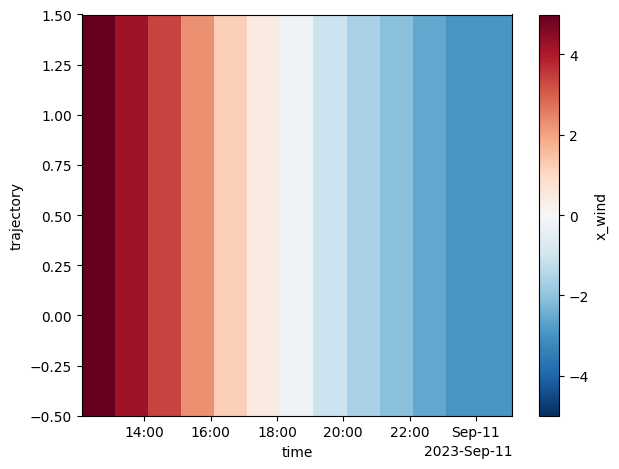

In [5]:
#xarray.Dataset allows for easy access of coordinates (o1_ds.coords), simulated and input variables (e.g. iceberg size, wind data), and model settings (e.g. coefficients, processes).
#Example for accessing variables and attribute: 
print(o1_ds.x_wind)
print(o1_ds.attrs['config_seed:wind_form_drag_coef'])
#It also makes plots easy:
o1_ds.x_wind.plot()

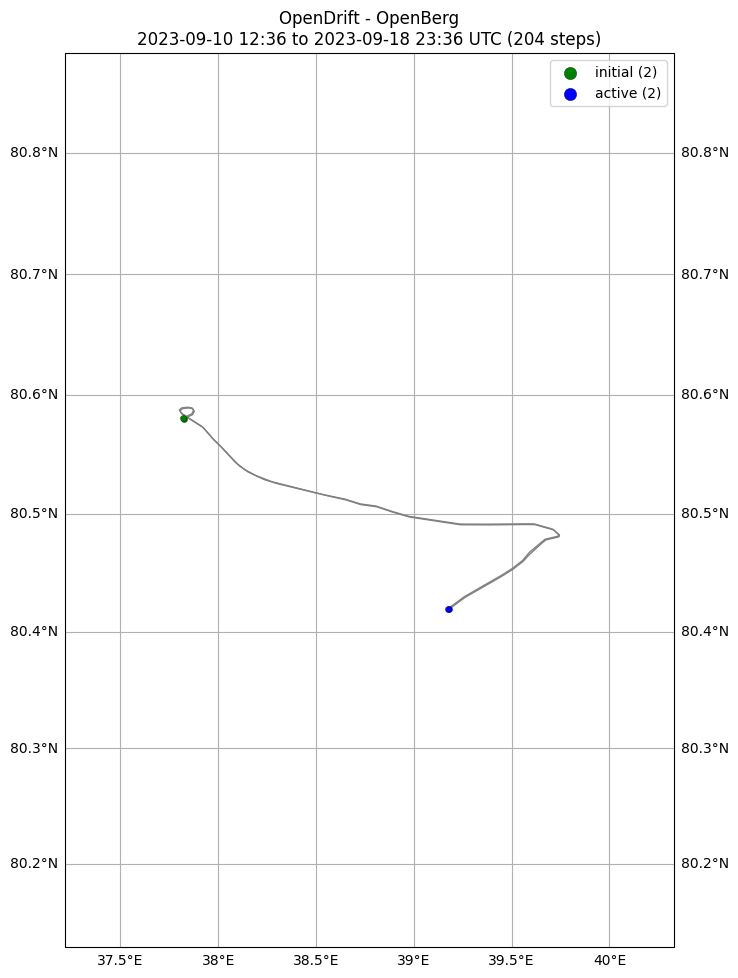

(<GeoAxes: title={'center': 'OpenDrift - OpenBerg\n2023-09-10 12:36 to 2023-09-18 23:36 UTC (204 steps)'}>,
 <Figure size 748.84x1100 with 1 Axes>)

In [6]:
# PLOT map of iceberg drift trajectory
#The model has inbuilt plotting functions. For those you have to use o1 which is type "opendrift.models.openberg.OpenBerg" object (not a Dataset).
o1.plot(fast=True)

In [7]:
# PLOT comparing different simulation runs and input data on map
o1.plot(compare=[o2,o3], legend=['Topaz5', 'Topaz4', 'Glorys'], background=['x_sea_water_velocity', 'y_sea_water_velocity'], 
        fast=False,filename='../results/opendrift_demo.png')

HTTPError: HTTP Error 404: Not Found

HTTPError: HTTP Error 404: Not Found

<Figure size 748.837x1100 with 1 Axes>

In [ ]:
# PLOT timeseries of variable or iceberg property, e.g. wind, iceberg length. You get the variable names from looking at o1_ds.
o1.plot_property('x_wind')

In [ ]:
# PLOT animated drift trajectory map
o1.animation(fast=True,filename='./simulation.gif',background=['sea_water_temperature','sea_water_temperature'],show_trajectories=True,
            compare=[o2,o3],legend=['Topaz5', 'Topaz4', 'Glorys']) #more animation options:color='z', buffer=.1
Image(url='../results/simulation.gif')

